# 04 - Lake inventory and data quality

What is actually inside the parquet lakes, and where the raw data misbehaves.
Everything here reads from disk only: no API calls, no network.

The notebook answers four questions:

1. **What is on disk?** Every lake, its layout, file count, size and row count.
2. **What does it cover?** Tickers and rows per year, listings and delistings, the trading calendar.
3. **Where is it wrong?** Impossible bars, empty tickers, zero prices, suspicious gaps.
4. **Do the adjustments explain the extremes?** The biggest overnight moves before and after adjustment.

Cost: a few minutes. The day lake is read in full (46 M rows); the minute lake is
touched only through parquet metadata and its per-day index sidecars.

## 1. Configuration

`POLYGON_LAKE_ROOT` points at the lake root. Set it in the environment to run this
against a different machine's lakes; nothing below hard-codes a path.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import pyarrow.compute as pc
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

LAKE = Path(os.environ.get("POLYGON_LAKE_ROOT", Path.home() / "local" / "parquet_lake"))
assert LAKE.is_dir(), f"lake root not found: {LAKE}  (set POLYGON_LAKE_ROOT)"

DAY_RAW = LAKE / "day" / "all"
DAY_ADJ = LAKE / "day_adj" / "all_adjusted"
MIN_RAW = LAKE / "minute" / "all"
MIN_ADJ = LAKE / "minute_adj" / "all_adjusted"

def data_files(root: Path) -> list[Path]:
    """Parquet data files of a lake: no `.idx.parquet` sidecars, no `manifest_*.json`."""
    return sorted(p for p in root.rglob("*.parquet") if not p.name.endswith(".idx.parquet"))

def read_lake(root: Path, columns: list[str]) -> pd.DataFrame:
    """Read a whole market-layout lake, dictionary encoding `ticker` so 33 k repeated symbols
    cost a few bytes a row instead of a python string each."""
    t = pq.read_table(data_files(root), columns=columns)
    i = t.schema.get_field_index("ticker")
    return t.set_column(i, "ticker", t.column("ticker").dictionary_encode()).to_pandas()

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
print("lake root:", LAKE)

lake root: /Users/mengren/local/parquet_lake


## 2. What is on disk

Row counts come from the parquet footers, so this costs milliseconds per file and
never decodes a data page. Sidecar files (`*.idx.parquet`) are the per-ticker row
index of a market-layout minute day file; they are counted separately.

In [2]:
def lake_stats(root: Path) -> dict:
    """File count, bytes and row count for one lake, from parquet metadata only."""
    if not root.is_dir():
        return {"lake": root.name, "exists": False}
    data = data_files(root)
    side = list(root.rglob("*.idx.parquet"))
    depth = len(data[0].relative_to(root).parts) if data else 0
    return {
        "lake": str(root.relative_to(LAKE)),
        "layout": "market" if any(d.name[:4].isdigit() and len(d.name) == 4 for d in root.iterdir() if d.is_dir()) else "ticker",
        "period": {1: "year", 2: "month", 3: "day"}.get(depth, f"depth {depth}"),
        "files": len(data),
        "sidecars": len(side),
        "GB": round(sum(p.stat().st_size for p in data + side) / 2**30, 1),
        "rows": sum(pq.ParquetFile(p).metadata.num_rows for p in data),
    }

inventory = pd.DataFrame([lake_stats(r) for r in (DAY_RAW, DAY_ADJ, MIN_RAW, MIN_ADJ)])
inventory["rows"] = inventory["rows"].map("{:,}".format)
inventory["files"] = inventory["files"].map("{:,}".format)
inventory

,lake,layout,period,files,sidecars,GB,rows
0,day/all,market,month,264,0,0.8,"46,490,595"
1,day_adj/all_adjusted,market,month,264,0,2.4,"46,490,595"
2,minute/all,market,day,"5,517",5517,93.1,"7,042,253,913"
3,minute_adj/all_adjusted,market,day,"5,517",5517,219.8,"7,042,253,913"


Both granularities use the **market layout**: one file per period holding every ticker,
sorted ticker-major. The day lake partitions by month, the minute lake by day. The 5,517
minute sidecars mean every minute day file has its per-ticker row index, which is what
makes single-symbol reads cheap (notebook 06).

## 3. Loading the day lake

The whole unadjusted day lake fits in memory comfortably once `ticker` is dictionary
encoded. `datetime` is tz-aware US/Eastern in the unadjusted lakes, so the ET trading
date is just the normalised date.

In [3]:
day = read_lake(DAY_RAW, ["datetime", "ticker", "open", "high", "low", "close", "volume", "transactions"])
day["date"] = day["datetime"].dt.normalize().dt.tz_localize(None)
day["year"] = day["date"].dt.year
print(f"{len(day):,} rows x {day.shape[1]} cols, {day.memory_usage(deep=True).sum() / 2**30:.1f} GB in memory")
print(f"{day['ticker'].nunique():,} tickers, {day['date'].nunique():,} trading days, "
      f"{day['date'].min().date()} to {day['date'].max().date()}")
day.head(3)

46,490,595 rows x 10 cols, 3.1 GB in memory
33,708 tickers, 5,517 trading days, 2003-09-10 to 2025-08-13


,datetime,ticker,open,high,low,close,volume,transactions,date,year
0,2003-09-10 00:00:00-04:00,A,25.40,25.580,24.41,24.49,2869700,2301,2003-09-10,2003
1,2003-09-11 00:00:00-04:00,A,24.57,25.180,24.45,25.04,2075400,1907,2003-09-11,2003
2,2003-09-12 00:00:00-04:00,A,25.04,25.114,24.55,24.97,2017700,1542,2003-09-12,2003


## 4. Coverage through time

How many symbols the market carried each year, and how many rows that produced.

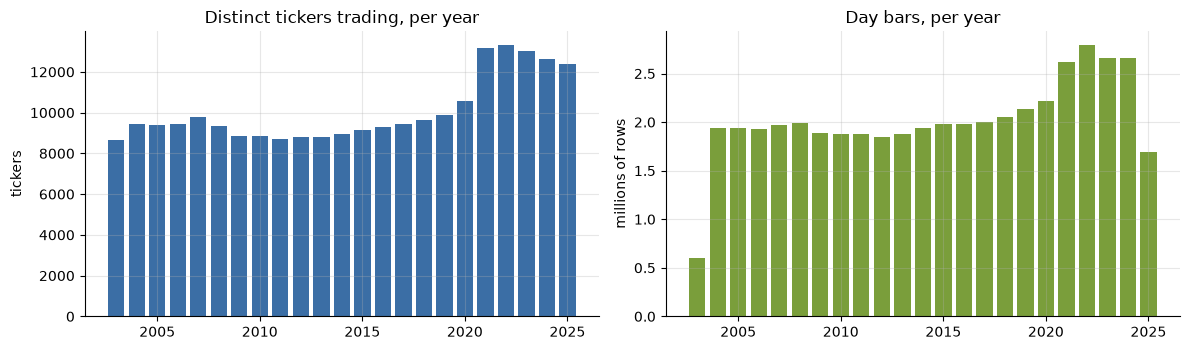

,rows,tickers,trading_days,dollar_vol
year,,,,
2003,"605,841",8646,79,291669066341
2004,"1,935,189",9434,252,971522516153
2005,"1,934,750",9390,252,1026410181815
2006,"1,932,790",9435,251,1210515593295
2007,"1,974,279",9781,251,1520874383841
2008,"1,995,235",9342,253,2232155486801
2009,"1,892,293",8875,252,2457386485132
2010,"1,876,075",8856,252,2131021777282
2011,"1,879,131",8715,252,1967457442210


In [4]:
per_year = day.groupby("year").agg(rows=("close", "size"), tickers=("ticker", "nunique"),
                                   trading_days=("date", "nunique"), dollar_vol=("volume", "sum"))
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].bar(per_year.index, per_year["tickers"], color="#3b6ea5")
ax[0].set_title("Distinct tickers trading, per year"); ax[0].set_ylabel("tickers")
ax[1].bar(per_year.index, per_year["rows"] / 1e6, color="#7a9e3b")
ax[1].set_title("Day bars, per year"); ax[1].set_ylabel("millions of rows")
for a in ax:
    a.set_xlabel("")
fig.tight_layout(); plt.show()
per_year.assign(rows=lambda d: d["rows"].map("{:,}".format)).head(30)

The dip after 2008 and the climb from 2020 are real market history: delistings in the
crisis, then the SPAC and ETF boom. 2025 is a partial year (the flat files end in August).

## 5. Trading calendar

A market-wide day lake should have one file entry per NYSE session. Rather than pull an
exchange calendar, we check the two things that actually indicate a problem: sessions
whose spacing is wrong, and sessions where far fewer symbols traded than usual.

In [5]:
days = pd.Series(sorted(day["date"].unique()))
gaps = days.diff().dt.days
long_gaps = pd.DataFrame({"session": days[gaps > 4], "days_since_previous": gaps[gaps > 4]})
full_years = days.dt.year.value_counts().drop([days.dt.year.min(), days.dt.year.max()])
print(f"{len(days):,} sessions, {days.dt.year.nunique()} calendar years")
print(f"sessions per complete year: min {full_years.min()}, median {full_years.median():.0f}, max {full_years.max()}")
print(f"gaps longer than a long weekend: {len(long_gaps)}")
long_gaps.assign(session=lambda d: d["session"].dt.date)

5,517 sessions, 23 calendar years
sessions per complete year: min 250, median 252, max 253
gaps longer than a long weekend: 2


,session,days_since_previous
834,2007-01-03,5.0
2302,2012-10-31,5.0


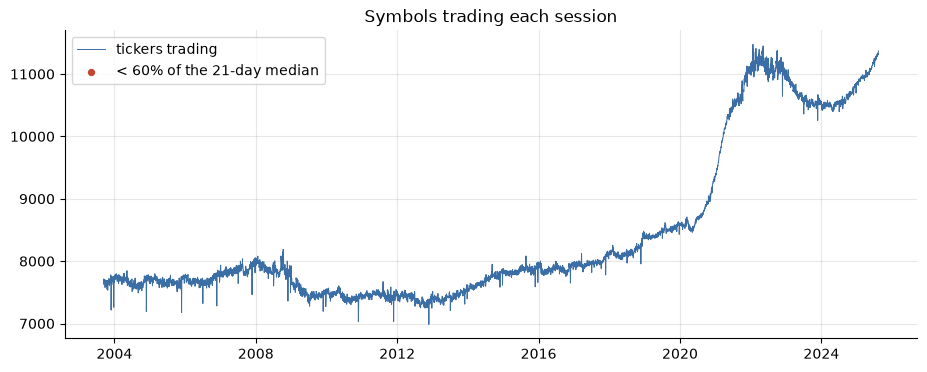

unusually thin sessions: 0


,tickers,pct_of_median
date,,


In [6]:
per_day = day.groupby("date")["ticker"].nunique()
med = per_day.rolling(21, center=True, min_periods=5).median()
thin = per_day[per_day < 0.6 * med]
fig, ax = plt.subplots()
ax.plot(per_day.index, per_day.values, lw=.7, color="#3b6ea5", label="tickers trading")
ax.scatter(thin.index, thin.values, s=18, color="#c4462f", zorder=3, label="< 60% of the 21-day median")
ax.set_title("Symbols trading each session"); ax.legend(loc="upper left"); plt.show()
print(f"unusually thin sessions: {len(thin)}")
thin.rename("tickers").to_frame().assign(pct_of_median=lambda d: (d["tickers"] / med[d.index]).round(2))

Every complete year has between 250 and 253 sessions, which is the correct NYSE count, and
no session is unusually thin: even the half days (the afternoon after Thanksgiving, Christmas
Eve) carry their full roster of symbols, because a shortened session still prints a day bar.

The two long gaps are real market closures, and finding exactly these two is a good sign:

- **2007-01-03** follows a four-day break: New Year plus 2 January, the national day of
  mourning for Gerald Ford.
- **2012-10-31** follows the two-day Hurricane Sandy closure of 29 and 30 October.

## 6. Data quality checks

Each check counts rows that are impossible or implausible on their face.

In [7]:
o, h, l, c, v = (day[k] for k in ("open", "high", "low", "close", "volume"))
checks = {
    "null ticker": day["ticker"].isna().sum(),
    "null or NaN close": c.isna().sum(),
    "close <= 0": (c <= 0).sum(),
    "any OHLC <= 0": ((o <= 0) | (h <= 0) | (l <= 0) | (c <= 0)).sum(),
    "high < low": (h < l).sum(),
    "close outside [low, high]": ((c < l) | (c > h)).sum(),
    "open outside [low, high]": ((o < l) | (o > h)).sum(),
    "volume == 0": (v == 0).sum(),
    "volume < 0": (v < 0).sum(),
    "transactions == 0": (day["transactions"] == 0).sum(),
    "duplicate (ticker, date)": day.duplicated(["ticker", "date"]).sum(),
}
quality = pd.DataFrame({"rows": pd.Series(checks)})
quality["share"] = (quality["rows"] / len(day)).map("{:.4%}".format)
quality["rows"] = quality["rows"].map("{:,}".format)
quality

,rows,share
null ticker,0,0.0000%
null or NaN close,0,0.0000%
close <= 0,0,0.0000%
any OHLC <= 0,0,0.0000%
high < low,0,0.0000%
"close outside [low, high]",0,0.0000%
"open outside [low, high]",0,0.0000%
volume == 0,"166,770",0.3587%
volume < 0,0,0.0000%
transactions == 0,"166,770",0.3587%


Every *bar-level* invariant holds: no crossed bars, no closes outside the day's range, no
non-positive prices. Zero-volume rows are a real Polygon artefact for symbols that printed a
quote but no trade, and they always carry zero transactions too.

The duplicate ticker-days are a genuine defect, and worth a section of their own.

### Duplicate ticker-days: a ticker-casing collision

29 k ticker-days carry two rows. They are not repeated ingests: the two rows hold different
prices and volumes. Tracing one back to the flat file shows what happened.

In [8]:
dups = day[day.duplicated(["ticker", "date"], keep=False)]
print(f"{len(dups):,} rows over {len(dups.drop_duplicates(['ticker', 'date'])):,} ticker-days, {dups['ticker'].nunique()} distinct tickers")
worst = dups["ticker"].value_counts().head(10)
print("most affected:", ", ".join(f"{t} ({n})" for t, n in worst.items()))
dups[dups["ticker"] == worst.index[0]].sort_values("date").head(4)[
    ["date", "ticker", "open", "high", "low", "close", "volume", "transactions"]]

58,516 rows over 29,258 ticker-days, 90 distinct tickers
most affected: CPS (5272), CPK (5046), AAP (4520), CPF (4196), CPV (4152), CPN (3736), CPE (3520), BCPC (3236), CPO (2948), TPC (2754)


,date,ticker,open,high,low,close,volume,transactions
22883,2003-09-10,CPS,24.68,24.70,24.53,24.60,201900,122
22884,2003-09-10,CPS,34.31,34.55,34.20,34.35,1630200,1139
22885,2003-09-11,CPS,24.60,24.60,24.46,24.59,104200,112
22886,2003-09-11,CPS,34.38,34.38,33.53,33.90,905800,1257


Now the same ticker and session in the source flat file, before the pipeline touched it.

In [9]:
import csv, gzip

FLAT = Path(os.environ.get("POLYGON_FLATFILES", Path.home() / "local" / "flatfiles"))
probe_t, probe_d = worst.index[0], dups.loc[dups["ticker"] == worst.index[0], "date"].min()
src_csv = FLAT / "day_aggs_v1" / f"{probe_d:%Y/%m/%Y-%m-%d}.csv.gz"
if src_csv.exists():
    raw = list(csv.reader(gzip.open(src_csv, "rt")))
    hits = [r for r in raw[1:] if r[0].strip().upper() == probe_t]
    print(f"{src_csv.name}: {len(hits)} rows normalise to {probe_t}")
    print(pd.DataFrame(hits, columns=raw[0])[["ticker", "open", "close", "volume", "transactions"]].to_string(index=False))
else:
    print(f"flat files not at {FLAT}; set POLYGON_FLATFILES to re-run this cell")

2003-09-10.csv.gz: 2 rows normalise to CPS
ticker  open close  volume transactions
   CpS 24.68  24.6  201900          122
   CPS 34.31 34.35 1630200         1139


**Polygon encodes share class in the letter case of the ticker.** `AAp` is not a typo for
`AAP`: it is a different security. The ingester uppercases every ticker, so the two
histories are merged into one symbol. The reference table names them:

In [10]:
ref = pd.read_parquet(LAKE / "refdata" / "_market" / "market_tickers.parquet",
                      columns=["ticker", "name", "type", "active"])
pd.concat([ref[ref["ticker"].str.upper() == t].assign(collides_with=t) for t in worst.index[:4]])[
    ["collides_with", "name", "type", "active"]].reset_index(drop=True)

,collides_with,name,type,active
0,CPS,Cooper-Standard Automotive Inc.,CS,True
1,CPS,"Citigroup Inc. Depositary Shares, each represe...",PFD,False
2,CPK,Chesapeake Utilities,CS,True
3,CPK,"Citigroup Inc. Depositary Shares, Each Represe...",PFD,False
4,AAP,ADVANCE AUTO PARTS INC,CS,True
5,AAP,Alcoa Inc. $3.75 Preferred Stock,PFD,False
6,CPF,Central Pacific Financial Corporation,CS,True
7,CPF,CITIGROUP CAP XIX ENHANCED TRUST PF SECS- TRUP...,SP,False


So a preferred share's bars are being mixed into the common stock's series for these symbols.
The blast radius is small but the rows are wrong, not merely noisy:

In [11]:
impact = pd.DataFrame({
    "affected tickers": [dups["ticker"].nunique()],
    "affected ticker-days": [len(dups.drop_duplicates(["ticker", "date"]))],
    "affected rows": [len(dups)],
    "share of day lake": [f"{len(dups) / len(day):.3%}"],
}).T.rename(columns={0: "value"})
print("per year:", dups.groupby(dups["date"].dt.year).size().to_dict())
impact

per year: {2003: 1142, 2004: 2610, 2005: 2006, 2006: 3200, 2007: 3442, 2008: 4160, 2009: 4248, 2010: 4064, 2011: 4582, 2012: 3888, 2013: 2370, 2014: 2572, 2015: 2366, 2016: 2744, 2017: 2316, 2018: 1636, 2019: 1518, 2020: 1956, 2021: 1822, 2022: 2180, 2023: 1698, 2024: 1384, 2025: 612}


,value
affected tickers,90
affected ticker-days,29258
affected rows,58516
share of day lake,0.126%


This is a pipeline bug, not a data-source problem, and fixing it means preserving the
original case at ingest so `AAP` and `AAp` stay separate symbols. It is filed as follow-up
work; until then, **treat these 90 symbols as unreliable** and de-duplicate by keeping the
higher-volume row, which is the common stock in every case sampled here.

In [12]:
day = day.sort_values("volume").drop_duplicates(["ticker", "date"], keep="last").sort_values(["ticker", "date"])
print(f"after de-duplication: {len(day):,} rows, {day.duplicated(['ticker', 'date']).sum()} duplicate ticker-days")

after de-duplication: 46,461,337 rows, 0 duplicate ticker-days


### The empty-ticker rows

The minute flat files contain a handful of rows whose ticker field is blank and whose
prices are all zero. They survive ingest as a null ticker. The day lake has none, because
those rows never aggregated into a day bar. Found through parquet null statistics, so no
data pages are decoded.

In [13]:
def null_ticker_rows(root: Path) -> pd.DataFrame:
    rows = []
    for p in data_files(root):
        pf = pq.ParquetFile(p)
        i = pf.schema_arrow.get_field_index("ticker")
        n = sum(pf.metadata.row_group(g).column(i).statistics.null_count for g in range(pf.metadata.num_row_groups))
        if n:
            rows.append({"file": str(p.relative_to(root)), "null_ticker_rows": n})
    return pd.DataFrame(rows)

nulls = null_ticker_rows(MIN_RAW)
print(f"minute lake: {len(nulls)} files carry {nulls['null_ticker_rows'].sum() if len(nulls) else 0} null-ticker rows "
      f"({nulls['file'].str[:4].min()}-{nulls['file'].str[:4].max()})" if len(nulls) else "minute lake: none")
print(f"day lake: {null_ticker_rows(DAY_RAW)['null_ticker_rows'].sum() if len(null_ticker_rows(DAY_RAW)) else 0} null-ticker rows")
nulls.head(8)

minute lake: 37 files carry 365 null-ticker rows (2006-2014)
day lake: 0 null-ticker rows


,file,null_ticker_rows
0,2006/08/31.parquet,9
1,2006/09/01.parquet,10
2,2006/09/05.parquet,7
3,2006/09/06.parquet,14
4,2006/09/07.parquet,13
5,2006/09/08.parquet,9
6,2006/09/11.parquet,7
7,2006/09/12.parquet,10


Worth knowing but not worth repairing in place: 365 rows of a 7-billion-row lake, all with
zero prices and zero volume, so any filter on price or volume removes them. Filter with
`df[df["ticker"].notna()]` if a groupby would otherwise produce a NaN bucket.

## 7. Price and volume distributions

Where the market actually lives, on log axes because both span nine orders of magnitude.

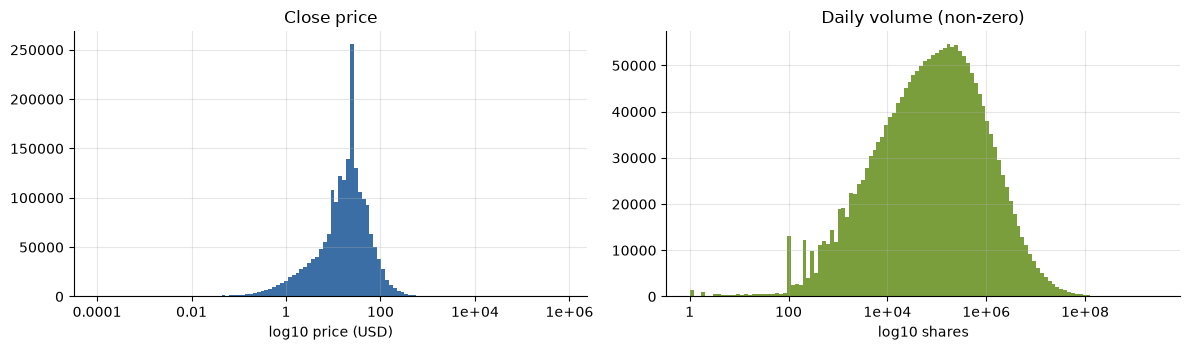

,count,mean,std,min,1%,25%,50%,75%,99%,max
close,46461337.0,63.386344,3334.112891,0.0001,0.21,8.83,20.41,35.0399,222.83,809350.0


In [14]:
sample = day.loc[day["close"] > 0, ["close", "volume"]].sample(2_000_000, random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(np.log10(sample["close"]), bins=120, color="#3b6ea5")
ax[0].set_title("Close price"); ax[0].set_xlabel("log10 price (USD)")
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{10**x:,.4g}"))
nz = sample.loc[sample["volume"] > 0, "volume"]
ax[1].hist(np.log10(nz), bins=120, color="#7a9e3b")
ax[1].set_title("Daily volume (non-zero)"); ax[1].set_xlabel("log10 shares")
ax[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{10**x:,.4g}"))
fig.tight_layout(); plt.show()
day["close"].describe(percentiles=[.01, .25, .5, .75, .99]).to_frame("close").T

## 8. Symbols with no reference entry

Every ticker in the price lake should appear in Polygon's tickers reference. The ones that do
not are mostly exchange **test symbols**, which print synthetic prices and must be excluded
from any analysis of real returns.

In [15]:
lake_tickers = pd.Index(day["ticker"].cat.categories)
unknown = lake_tickers.difference(pd.Index(ref["ticker"].str.upper().unique()))
unk_rows = day[day["ticker"].isin(unknown)]
print(f"{len(unknown):,} of {len(lake_tickers):,} lake tickers have no reference row "
      f"({len(unk_rows):,} rows, {len(unk_rows) / len(day):.3%})")
odd = unk_rows.groupby("ticker", observed=True).agg(rows=("close", "size"), max_close=("close", "max")) \
              .sort_values("max_close", ascending=False).head(10)
print("\nhighest-priced unknown symbols (the classic NYSE/Nasdaq test tickers):")
odd

1,843 of 33,708 lake tickers have no reference row (713,598 rows, 1.536%)

highest-priced unknown symbols (the classic NYSE/Nasdaq test tickers):


,rows,max_close
ticker,,
ZTEST,2186,499999.995
NTEST.G,30,300010.000
AAZST,137,199999.990
ZYSZZ,3,199999.990
ZYYZZ,28,199999.990
ZBZZT,69,199999.990
ZJZZT,903,199999.990
ZXZZT,4276,199999.990
ZWZZT,3655,199999.990


`ZVZZT`, `ZXZZT`, `ZWZZT` and friends are Nasdaq test symbols that quote at absurd prices.
They are excluded from the return analysis below.

## 9. Do the adjustments explain the extreme moves?

The sharpest test of a corporate-actions pipeline: take the largest overnight jumps in raw
prices and check that the split-adjusted series removes them. Anything left is either a real
move or a corporate action the splits table does not carry.

In [16]:
real = day[~day["ticker"].isin(unknown)]
liquid = real.loc[real["volume"] * real["close"] > 1e6, ["ticker", "date", "close"]].sort_values(["ticker", "date"])
liquid["prev"] = liquid.groupby("ticker", observed=True)["close"].shift(1)
liquid["raw_gap"] = liquid["close"] / liquid["prev"]
extremes = liquid.loc[liquid["raw_gap"].notna() & ((liquid["raw_gap"] > 4) | (liquid["raw_gap"] < 0.25))].copy()
print(f"{len(extremes):,} overnight gaps beyond 4x or 1/4x on symbols trading over $1 M that day")

adj = read_lake(DAY_ADJ, ["datetime", "ticker", "close_split", "volume", "id"])
adj["date"] = adj["datetime"].dt.tz_localize("UTC").dt.tz_convert("US/Eastern").dt.normalize().dt.tz_localize(None)
adj = adj.sort_values("volume").drop_duplicates(["ticker", "date"], keep="last").sort_values(["ticker", "date"])
adj["prev_split"] = adj.groupby("ticker", observed=True)["close_split"].shift(1)
adj["adj_gap"] = adj["close_split"] / adj["prev_split"]

both = extremes.merge(adj[["ticker", "date", "adj_gap", "id"]], on=["ticker", "date"], how="left")
fixed = both["adj_gap"].between(0.25, 4)
print(f"explained by the split adjustment: {fixed.sum():,} of {len(both):,} ({fixed.mean():.1%})")
both.assign(raw_gap=lambda d: d["raw_gap"].round(2), adj_gap=lambda d: d["adj_gap"].round(3),
            date=lambda d: d["date"].dt.date)[["ticker", "date", "close", "raw_gap", "adj_gap", "id"]] \
    .sort_values("raw_gap", ascending=False).head(12)

5,094 overnight gaps beyond 4x or 1/4x on symbols trading over $1 M that day


explained by the split adjustment: 3,573 of 5,094 (70.1%)


,ticker,date,close,raw_gap,adj_gap,id
2298,COIN,2021-04-14,328.2800,2264.00,2264.000,BBG00ZGF7771
283,CHTR,2010-09-14,35.5000,1775.00,1775.000,BBG000VPGNR2
4922,BETS,2024-01-10,6.6100,1139.66,1.140,CIK__0001543268
2354,VTG,2025-07-16,74.8765,993.06,1.002,BBG01VXRNYQ6
4039,GMBL,2023-12-22,6.9100,658.10,1.645,BBG000Q8H8G0
136,AVR,2006-06-29,38.3700,639.50,767.400,NOFIGI__AVR#SEG1
5074,FMTO,2025-04-22,7.3300,610.83,1.222,BBG017VBWGD9
2758,GMAN,2019-03-19,49.0172,544.64,1.007,CIK__0001479026
1619,VC,2011-01-10,75.6500,504.33,3782.500,BBG0016T3GQ0
103,APP,2021-04-15,65.2000,495.82,580.588,BBG006HFPX77


Roughly seven in ten extreme gaps vanish once splits are applied. The survivors fall into two
honest categories rather than pipeline faults:

- **First-session artefacts.** A direct listing or a post-bankruptcy relisting prints a
  reference price that is not a tradeable close, so the first real session looks like a
  thousand-fold move. Coinbase on 2021-04-14 and Charter on 2010-09-14 are the clearest cases,
  and both show `raw_gap == adj_gap` because no split is involved.
- **Unresolved micro caps.** Reverse splits that Polygon's splits table does not carry, mostly
  on symbols whose `id` starts with `NOFIGI__`, meaning the security master could not resolve
  the company behind the ticker.

Neither is fixable from the lake alone, but both are easy to exclude: require a minimum price
and a listing history of more than one session before computing returns.

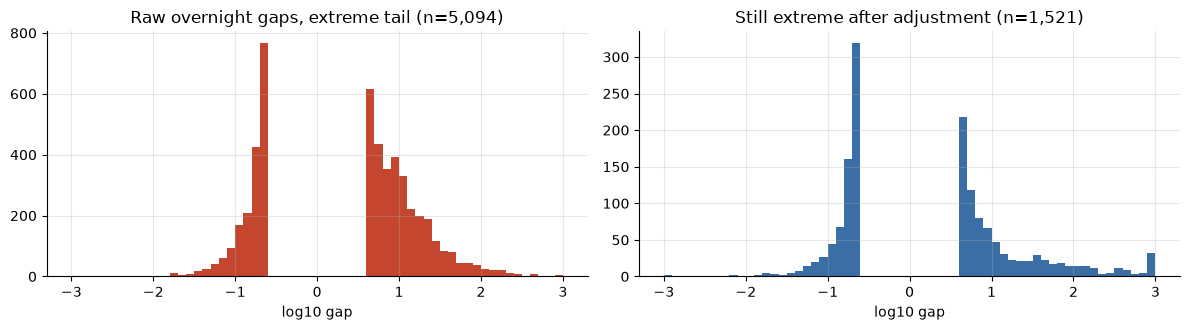

date,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
unexplained gaps,2,9,13,16,70,58,67,36,34,20,...,56,85,97,66,82,163,127,153,149,118


In [17]:
left = both.loc[~fixed].copy()
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
ax[0].hist(np.log10(both["raw_gap"].clip(1e-3, 1e3)), bins=60, color="#c4462f")
ax[0].set_title(f"Raw overnight gaps, extreme tail (n={len(both):,})"); ax[0].set_xlabel("log10 gap")
ax[1].hist(np.log10(left["adj_gap"].clip(1e-3, 1e3).dropna()), bins=60, color="#3b6ea5")
ax[1].set_title(f"Still extreme after adjustment (n={len(left):,})"); ax[1].set_xlabel("log10 gap")
fig.tight_layout(); plt.show()
left.groupby(left["date"].dt.year).size().rename("unexplained gaps").to_frame().T

## 10. The minute lake, from metadata

7 billion rows is too many to load, and unnecessary: the parquet footers give rows per day,
and the sidecars give per-ticker row counts without touching a data page.

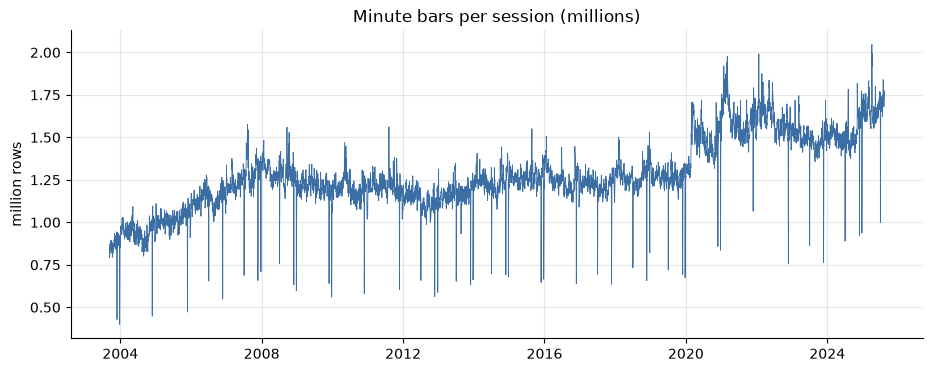

5,517 sessions, 7,042,253,913 rows, 92 GB


,sessions,rows,GB
year,,,
2003,79,"67,569,138",0.6
2004,252,"237,167,836",2.3
2005,252,"256,123,834",2.5
2006,251,"284,748,140",2.9
2007,251,"315,778,466",3.3
2008,253,"326,397,586",3.7
2009,252,"303,233,511",3.6
2010,252,"301,576,295",3.6
2011,252,"305,521,879",3.7


In [18]:
min_files = data_files(MIN_RAW)
meta = pd.DataFrame([{"date": pd.Timestamp(*(int(x) for x in (p.parts[-3], p.parts[-2], p.stem))),
                      "rows": pq.ParquetFile(p).metadata.num_rows,
                      "MB": p.stat().st_size / 2**20} for p in min_files])
meta["year"] = meta["date"].dt.year
fig, ax = plt.subplots()
ax.plot(meta["date"], meta["rows"] / 1e6, lw=.6, color="#3b6ea5")
ax.set_title("Minute bars per session (millions)"); ax.set_ylabel("million rows"); plt.show()
print(f"{len(meta):,} sessions, {meta['rows'].sum():,} rows, {meta['MB'].sum() / 1024:.0f} GB")
meta.groupby("year").agg(sessions=("rows", "size"), rows=("rows", "sum"), GB=("MB", lambda s: round(s.sum() / 1024, 1))) \
    .assign(rows=lambda d: d["rows"].map("{:,}".format))

The step up in 2021 is extended-hours coverage widening, not a change in the pipeline.

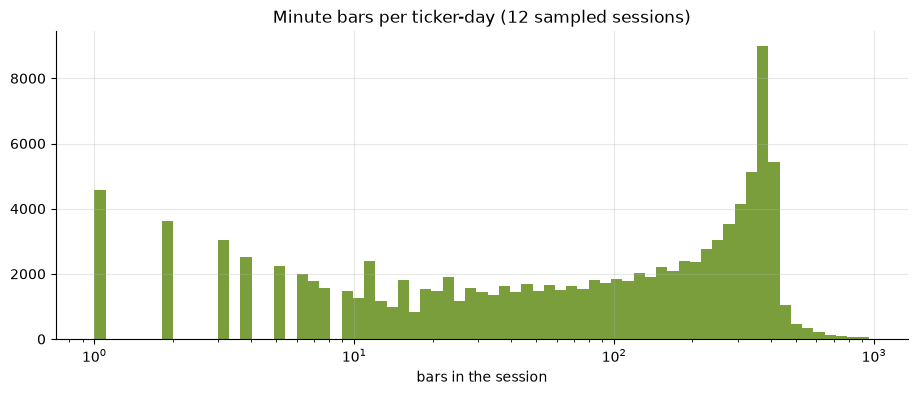

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
bars per ticker-day,109697.0,147.8,151.9,1.0,3.0,13.0,83.0,280.0,383.0,502.0,960.0


In [19]:
idx = pd.concat([pd.read_parquet(MIN_ADJ / f"{d:%Y/%m/%d}.idx.parquet")
                 for d in meta["date"].sample(12, random_state=3)], keys=range(12), names=["sample"])
fig, ax = plt.subplots()
ax.hist(idx["n_rows"], bins=np.logspace(0, np.log10(idx["n_rows"].max()), 70), color="#7a9e3b")
ax.set_xscale("log"); ax.set_title("Minute bars per ticker-day (12 sampled sessions)")
ax.set_xlabel("bars in the session"); plt.show()
idx["n_rows"].describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(1).to_frame("bars per ticker-day").T

The median symbol prints a few dozen bars a day and the busiest print the full extended
session. A minute lake is mostly sparse: that long left tail is why per-ticker files would
be a bad layout here, and why the market layout plus sidecar wins.

## 11. Summary

In [20]:
summary = pd.DataFrame([
    ("day bars (after de-duplication)", f"{len(day):,}"),
    ("minute bars", f"{meta['rows'].sum():,}"),
    ("tickers, day lake", f"{len(lake_tickers):,}"),
    ("sessions", f"{len(days):,}"),
    ("date range", f"{day['date'].min():%Y-%m-%d} to {day['date'].max():%Y-%m-%d}"),
    ("crossed or out-of-range bars", f"{int((h < l).sum() + ((c < l) | (c > h)).sum()):,}"),
    ("ticker-casing collisions (tickers / rows)", f"{dups['ticker'].nunique()} / {len(dups):,}"),
    ("tickers with no reference row", f"{len(unknown):,}"),
    ("null-ticker minute rows", f"{int(nulls['null_ticker_rows'].sum()) if len(nulls) else 0:,}"),
    ("extreme raw gaps explained by splits", f"{fixed.mean():.1%}"),
], columns=["metric", "value"]).set_index("metric")
summary

,value
metric,
day bars (after de-duplication),"46,461,337"
minute bars,"7,042,253,913"
"tickers, day lake","33,708"
sessions,"5,517"
date range,2003-09-10 to 2025-08-13
crossed or out-of-range bars,0
ticker-casing collisions (tickers / rows),"90 / 58,516"
tickers with no reference row,"1,843"
null-ticker minute rows,365


**Takeaways for anyone using these lakes**

- **Bar-level integrity is sound.** No crossed bars, no non-positive prices, no closes outside
  the day's range, and the trading calendar is exactly right, down to the Ford mourning day and
  the Hurricane Sandy closure.
- **One real bug, filed as follow-up: ticker casing.** Polygon distinguishes share classes by
  letter case and the ingester uppercases, merging about 90 preferred shares into their common
  namesake. Until it is fixed, de-duplicate on `(ticker, date)` keeping the higher-volume row,
  as this notebook does.
- **Exclude the test symbols.** A few dozen lake tickers have no reference row; the expensive
  ones are Nasdaq test tickers quoting near $200,000 and they will wreck any return study.
- **Use `close_split` across corporate actions.** It removes about seven in ten of the extreme
  overnight gaps; the rest are listing-day reference prices and unresolved `NOFIGI__` micro caps,
  both of which a minimum-price and minimum-history filter removes.
- **Never load the minute lake whole.** Parquet footers and the `.idx.parquet` sidecars answer
  most structural questions for free; notebook 06 covers reading it properly.